# ¿Puede el Machine Learning mejorar un portafolio del IPSA frente a estrategias clásicas?

**Curso:** INF 398 Introducción al Aprendizaje Automático

**Integrantes:** Carlos Tapia, Mauricio Pizarro y Brian Valenzuela
## Introducción

Este notebook responde una pregunta concreta: **¿puede un modelo de Machine Learning mejorar la construcción de un portafolio de acciones del IPSA respecto de estrategias clásicas de asignación de capital?**

El objetivo **no** es demostrar que el ML gana. El objetivo es una evaluación **honesta y fuera de muestra**: si el ML no mejora el desempeño, ese resultado es igualmente válido y se reporta como tal.

**Pipeline:** selección de acciones → retornos mensuales → ingeniería de features → predicción de retornos con ML (con `GridSearchCV` sólo sobre datos pasados) → esquema *walk-forward* sin fuga de información → optimización de portafolios (Markowitz, Ledoit-Wolf, mínima varianza, ML) → backtest con costos y restricciones → métricas → **bootstrap por bloques** para evaluar significancia.

**Estrategias comparadas:** 1/N (Equal-Weight), Markowitz clásico, Markowitz + Ledoit-Wolf, Mínima Varianza + Ledoit-Wolf, y ML + Ledoit-Wolf.

# 1. Carga de librerías y datos del mercado IPSA

Cargamos las dependencias, descargamos los precios mensuales del IPSA desde Yahoo Finance, exploramos el universo y construimos las *features* rezagadas (sin fuga de información).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import cvxpy as cp
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(42)

np.random.seed(42)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':0.3})

# ---------------- Configuracion ----------------
TICKERS = [
    'SQM-B.SN','COPEC.SN','BSANTANDER.SN','FALABELLA.SN','BCI.SN','CMPC.SN','CENCOSUD.SN',
    'CHILE.SN','AGUAS-A.SN','ANDINA-B.SN','CAP.SN','CCU.SN','COLBUN.SN','CONCHATORO.SN',
    'ENTEL.SN','PARAUCO.SN','ANTARCHILE.SN','QUINENCO.SN','GASCO.SN','RIPLEY.SN','SONDA.SN',
]
NOMBRES = {
    'SQM-B.SN':'SQM-B','COPEC.SN':'Copec','BSANTANDER.SN':'Santander','FALABELLA.SN':'Falabella',
    'BCI.SN':'BCI','CMPC.SN':'CMPC','CENCOSUD.SN':'Cencosud','CHILE.SN':'BChile','AGUAS-A.SN':'Aguas',
    'ANDINA-B.SN':'Andina','CAP.SN':'CAP','CCU.SN':'CCU','COLBUN.SN':'Colbun','CONCHATORO.SN':'ConchaToro',
    'ENTEL.SN':'Entel','PARAUCO.SN':'ParqueArauco','ANTARCHILE.SN':'AntarChile','QUINENCO.SN':'Quinenco',
    'GASCO.SN':'Gasco','RIPLEY.SN':'Ripley','SONDA.SN':'Sonda',
}
START_DATE, END_DATE = '2008-01-01', '2024-12-31'
RF_ANUAL   = 0.05
RF_MENSUAL = RF_ANUAL/12
COSTO_TX   = 0.001          # 0.1% por rebalanceo
VENTANA    = 36             # meses de entrenamiento walk-forward
LO, HI     = 0.0, 0.20      # cotas de peso por accion
MODELO_ML  = 'Ridge'        # 'Ridge' | 'Lasso' | 'ElasticNet' | 'RandomForest'
N_BOOT, BLOCK_LEN = 5000, 6 # bootstrap por bloques
print('Configuracion lista. Modelo ML:', MODELO_ML)

Configuracion lista. Modelo ML: Ridge


## Carga de datos

Descargamos precios de cierre ajustados desde Yahoo Finance, descartamos acciones con demasiados datos faltantes y construimos **retornos mensuales** (fin de mes). El universo final es el que sobrevive al filtro de disponibilidad desde 2008.

In [2]:
import os, glob

CACHE_DIR = 'datos'
os.makedirs(CACHE_DIR, exist_ok=True)

def descargar_precios(tickers, start, end, max_faltante=0.10, cache_dir=CACHE_DIR):
    previos = sorted(glob.glob(os.path.join(cache_dir, 'precios_raw_*.csv')))
    if previos:
        cache = previos[-1]
        raw = pd.read_csv(cache, index_col=0, parse_dates=True)
        print(f'Usando datos cacheados: {os.path.basename(cache)}')
    else:
        raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)['Close']
        cache = os.path.join(cache_dir, f"precios_raw_{pd.Timestamp.today().strftime('%Y-%m-%d')}.csv")
        raw.to_csv(cache)
        print(f'Descargado y guardado: {os.path.basename(cache)}')
    raw = raw.loc[:, raw.isna().mean() < max_faltante]      # descartar tickers muy incompletos
    raw = raw.ffill().dropna()
    return raw

def retornos_mensuales(precios):
    return precios.resample('ME').last().pct_change().dropna()

precios = descargar_precios(TICKERS, START_DATE, END_DATE)
tickers_ok = list(precios.columns)
nombres_ok = [NOMBRES.get(t, t) for t in tickers_ok]
precios.columns = nombres_ok
N = len(nombres_ok)

retornos = retornos_mensuales(precios).clip(-0.40, 0.40)   # recorte de outliers extremos
print(f'Acciones que pasaron el filtro: {N}')
print(f'Periodo retornos: {retornos.index[0].date()} -> {retornos.index[-1].date()}  ({len(retornos)} meses)')
print('Primera fecha valida por accion:')
print(precios.apply(lambda c: c.first_valid_index()).astype(str).to_string())

Descargado y guardado: precios_raw_2026-07-01.csv
Acciones que pasaron el filtro: 21
Periodo retornos: 2008-02-29 -> 2024-12-31  (203 meses)
Primera fecha valida por accion:
Aguas           2008-01-07
Andina          2008-01-07
AntarChile      2008-01-07
BCI             2008-01-07
Santander       2008-01-07
CAP             2008-01-07
CCU             2008-01-07
Cencosud        2008-01-07
BChile          2008-01-07
CMPC            2008-01-07
Colbun          2008-01-07
ConchaToro      2008-01-07
Copec           2008-01-07
Entel           2008-01-07
Falabella       2008-01-07
Gasco           2008-01-07
ParqueArauco    2008-01-07
Quinenco        2008-01-07
Ripley          2008-01-07
Sonda           2008-01-07
SQM-B           2008-01-07


## Análisis Exploratorio (EDA)

Cuatro vistas del universo: evolución de precios normalizados, retorno mensual promedio con dispersión, volatilidad anualizada por acción y matriz de correlaciones.

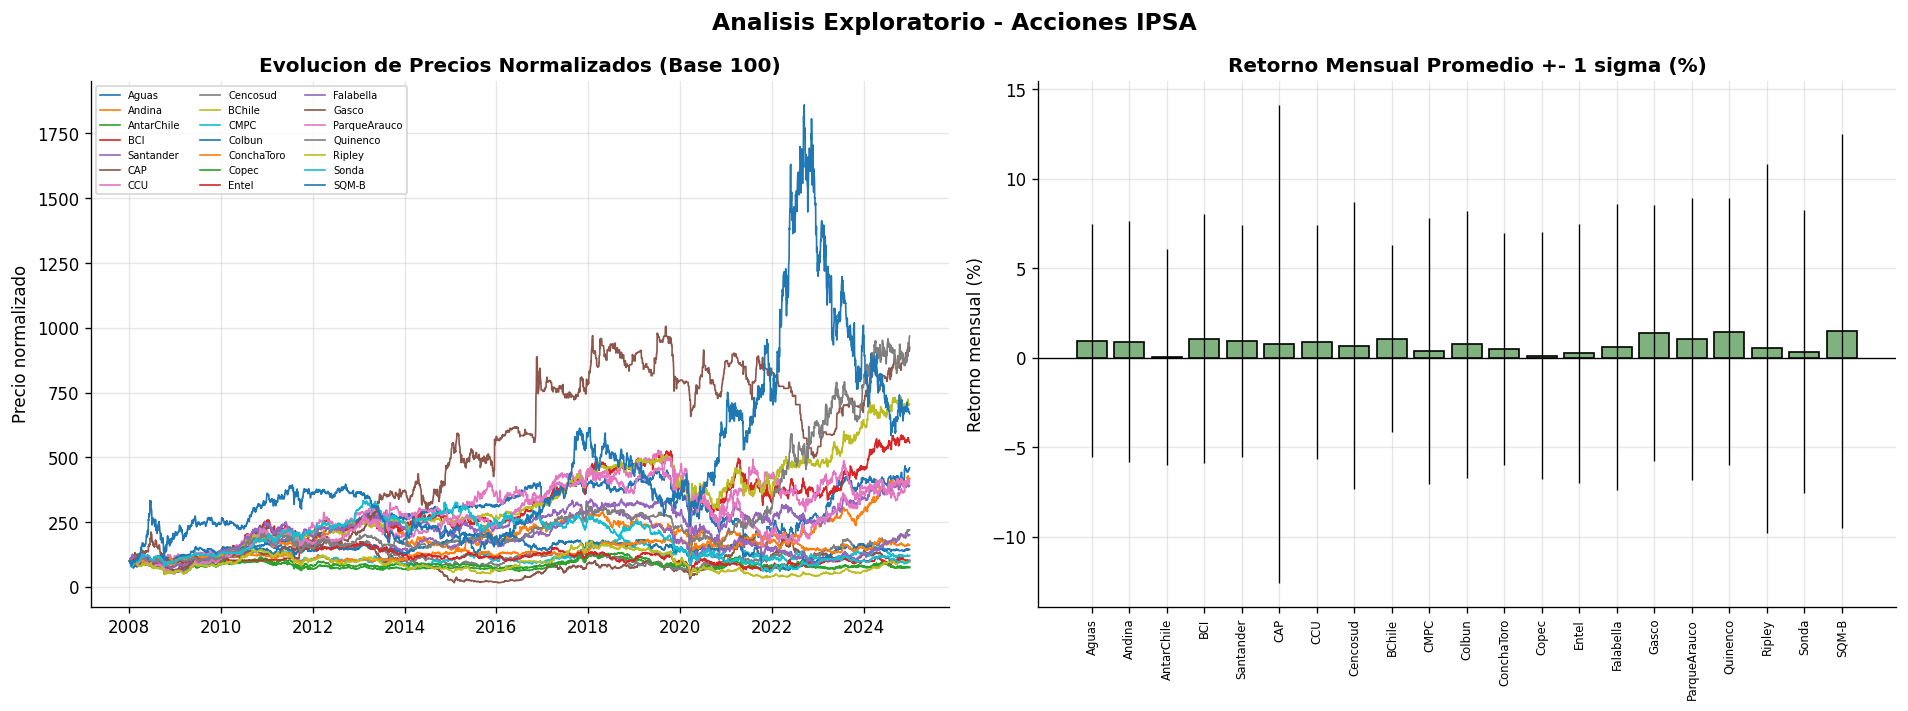

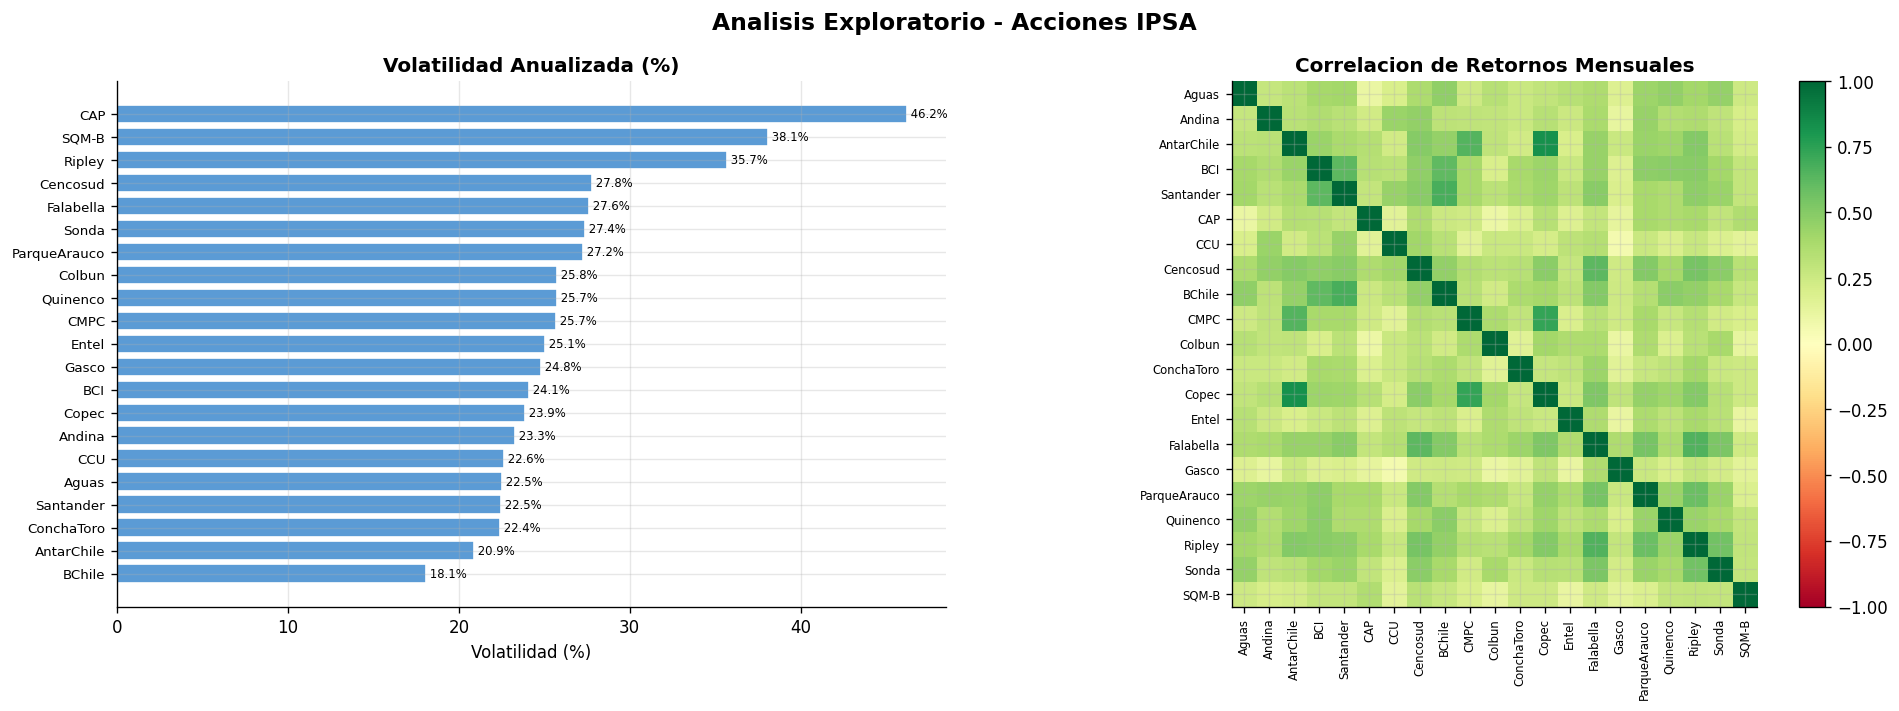

In [41]:
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

# Precios normalizados (base 100)
pn = precios / precios.iloc[0] * 100
for c in pn.columns:
    axes1[0].plot(pn.index, pn[c], lw=1, label=c)
axes1[0].set_title('Evolucion de Precios Normalizados (Base 100)', fontweight='bold')
axes1[0].set_ylabel('Precio normalizado'); axes1[0].legend(fontsize=6, ncol=3)

# Retorno mensual promedio +-1 sigma
mean_r = retornos.mean()*100; std_r = retornos.std()*100
order = mean_r.index
axes1[1].bar(range(N), mean_r[order], yerr=std_r[order], color='#7fb27f',
             edgecolor='black', error_kw={'lw':0.8})
axes1[1].axhline(0, color='black', lw=0.8)
axes1[1].set_xticks(range(N)); axes1[1].set_xticklabels(order, rotation=90, fontsize=7)
axes1[1].set_title('Retorno Mensual Promedio +- 1 sigma (%)', fontweight='bold')
axes1[1].set_ylabel('Retorno mensual (%)')

plt.suptitle('Analisis Exploratorio - Acciones IPSA', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_1.png', bbox_inches='tight', dpi=150); plt.show()


fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# Volatilidad anualizada
vol = (retornos.std()*np.sqrt(12)*100).sort_values()
axes2[0].barh(range(N), vol.values, color='#5b9bd5', edgecolor='white')
axes2[0].set_yticks(range(N)); axes2[0].set_yticklabels(vol.index, fontsize=8)
axes2[0].set_title('Volatilidad Anualizada (%)', fontweight='bold'); axes2[0].set_xlabel('Volatilidad (%)')
for i,v in enumerate(vol.values): axes2[0].text(v, i, f' {v:.1f}%', va='center', fontsize=7)

# Correlaciones
corr = retornos.corr()
im = axes2[1].imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
axes2[1].set_xticks(range(N)); axes2[1].set_xticklabels(corr.columns, rotation=90, fontsize=7)
axes2[1].set_yticks(range(N)); axes2[1].set_yticklabels(corr.columns, fontsize=7)
axes2[1].set_title('Correlacion de Retornos Mensuales', fontweight='bold')
plt.colorbar(im, ax=axes2[1], fraction=0.046)

plt.suptitle('Analisis Exploratorio - Acciones IPSA', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_2.png', bbox_inches='tight', dpi=150); plt.show()

## Construcción de Features

Para cada acción construimos 9 *features* a partir de sus retornos, **todas rezagadas con `shift(1)`** para garantizar que en el mes $t$ sólo se usa información hasta $t-1$:
momentum 1/3/6/12 meses, volatilidad rolling (3 y 6 meses), media móvil, desviación respecto a la media (reversión) y RSI. El *target* es el retorno del mes $t$.

In [4]:
def rsi_desde_retornos(r, window=6):
    g = r.clip(lower=0); l = (-r).clip(lower=0)
    ag = g.rolling(window).mean(); al = l.rolling(window).mean()
    rs = ag / al.replace(0, np.nan)
    return (100 - 100/(1+rs)).fillna(50)

def crear_features(ret_df):
    feats = []
    for col in ret_df.columns:
        r = ret_df[col]; f = pd.DataFrame(index=ret_df.index)
        f[f'{col}_mom1']  = r.shift(1)
        f[f'{col}_mom3']  = (1+r.shift(1))*(1+r.shift(2))*(1+r.shift(3)) - 1
        f[f'{col}_mom6']  = r.shift(1).rolling(6).apply(lambda x:(1+x).prod()-1)
        f[f'{col}_mom12'] = r.shift(1).rolling(12).apply(lambda x:(1+x).prod()-1)
        f[f'{col}_vol3']  = r.shift(1).rolling(3).std()
        f[f'{col}_vol6']  = r.shift(1).rolling(6).std()
        f[f'{col}_sma3']  = r.shift(1).rolling(3).mean()
        f[f'{col}_dev']   = r.shift(1) - r.shift(1).rolling(12).mean()
        f[f'{col}_rsi']   = rsi_desde_retornos(r, 6).shift(1)
        feats.append(f)
    X = pd.concat(feats, axis=1); y = ret_df
    idx = X.dropna().index.intersection(y.dropna().index)
    return X.loc[idx], y.loc[idx]

X_full, y_full = crear_features(retornos)
print(f'Matriz de features: {X_full.shape[0]} meses x {X_full.shape[1]} columnas ({X_full.shape[1]//N} por accion)')
print(f'Rango: {X_full.index[0].date()} -> {X_full.index[-1].date()}')
X_full.iloc[:3, :5]

Matriz de features: 191 meses x 189 columnas (9 por accion)
Rango: 2009-02-28 -> 2024-12-31


,Aguas_mom1,Aguas_mom3,Aguas_mom6,Aguas_mom12,Aguas_vol3
Date,,,,,
2009-02-28,0.127168,0.101695,0.014222,0.056534,0.102525
2009-03-31,-0.020513,0.021390,0.008701,0.045315,0.104548
2009-04-30,0.000000,0.104047,0.035246,0.024615,0.080002


# 2. Definición de los modelos y utilidades

Definimos el optimizador de Markowitz, los modelos ML que **predicen $\mu$** (Ridge, Lasso, ElasticNet, Random Forest) y el MLP de asignación directa (DFL). Importante: los modelos ML *no* reemplazan a Markowitz; le entregan su insumo $\mu$, y Markowitz **optimiza** los pesos a partir de ese $\mu$ y de la covarianza Ledoit–Wolf. El DFL es la excepción: mapea *features* $\to$ pesos directamente, sin pasar por $\mu$ ni por el optimizador. El motor de *backtest* corre las estrategias clásicas (1/N, Markowitz, Markowitz+LW, MinVar+LW) y el ML+LW en una sola pasada walk-forward.

## Optimización de portafolios (cvxpy)

Resolvemos dos problemas convexos con `cvxpy`, ambos con restricciones de peso $[\text{LO}, \text{HI}]$ y suma 1:

- **Mínima varianza:** $\min_w\ w^\top\Sigma w$. No usa retornos esperados.
- **Máximo Sharpe:** vía la transformación de Schaible (programación fraccional), que convierte el problema en un QP convexo. Si no hay exceso de retorno positivo alcanzable, cae a mínima varianza.

La covarianza se estima de dos formas: muestral y con **shrinkage de Ledoit-Wolf**.

In [5]:
def cov_ledoit(window):
    lw = LedoitWolf().fit(window)
    return lw.covariance_, lw.shrinkage_

def optimizar(mu, Sigma, objetivo='max_sharpe', lo=LO, hi=HI, rf=RF_MENSUAL):
    '''Optimizador convexo (cvxpy). objetivo: 'min_var' o 'max_sharpe'.'''
    n = len(mu); S = (Sigma + Sigma.T) / 2
    try:
        if objetivo == 'min_var':
            w = cp.Variable(n)
            P = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(S))),
                           [cp.sum(w) == 1, w >= lo, w <= hi])
            P.solve(solver=cp.OSQP, verbose=False)
            if w.value is None: return np.ones(n)/n
            wv = np.clip(w.value, lo, hi); return wv/wv.sum()
        else:  # max_sharpe (Schaible): min y'Sy s.t. (mu-rf)'y=1, cotas homogeneas
            ex = mu - rf
            if np.max(ex) <= 1e-10:
                return optimizar(mu, S, 'min_var', lo, hi, rf)
            y = cp.Variable(n); k = cp.sum(y)
            cons = [ex @ y == 1, y >= 0, y <= hi*k]
            if lo > 0: cons.append(y >= lo*k)
            P = cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(S))), cons)
            P.solve(solver=cp.OSQP, verbose=False)
            if y.value is None or y.value.sum() <= 1e-12:
                return optimizar(mu, S, 'min_var', lo, hi, rf)
            w = np.clip(y.value/y.value.sum(), lo, hi); return w/w.sum()
    except Exception:
        return np.ones(n)/n

# verificacion rapida
mu_t = retornos.mean().values; cov_t,_ = cov_ledoit(retornos.values[-36:])
w_ms = optimizar(mu_t, cov_t, 'max_sharpe'); w_mv = optimizar(mu_t, cov_t, 'min_var')
print(f'max_sharpe -> suma={w_ms.sum():.3f}, max peso={w_ms.max():.3f} (cota={HI})')
print(f'min_var    -> suma={w_mv.sum():.3f}, max peso={w_mv.max():.3f}')

max_sharpe -> suma=1.000, max peso=0.200 (cota=0.2)
min_var    -> suma=1.000, max peso=0.161


## Entrenamiento ML y Grid Search

El notebook soporta varios modelos (Ridge, Lasso, Elastic Net y, opcionalmente, Random Forest). En cada paso del walk-forward, los hiperparámetros se eligen con **`GridSearchCV`** usando **`TimeSeriesSplit`** sobre la ventana de entrenamiento: la búsqueda **sólo ve datos pasados**, evitando fuga de información. Cada acción se predice con **sus propias features** (evita el sobreajuste de tener más variables que observaciones).

In [36]:
from collections import defaultdict
ALPHAS_LOG = defaultdict(list)

def construir_modelo(nombre):
    if nombre == 'Ridge':        return Ridge(), {'alpha':[0.1,1.0,10.0,100.0,1000.0,10000.0]}
    if nombre == 'Lasso':        return Lasso(max_iter=5000), {'alpha':[0.001,0.01,0.1,1.0]}
    if nombre == 'ElasticNet':   return ElasticNet(max_iter=5000), {'alpha':[0.01,0.1,1.0],'l1_ratio':[0.2,0.5,0.8]}
    if nombre == 'RandomForest': return RandomForestRegressor(n_estimators=50, random_state=0, n_jobs=-1), {'max_depth':[3,5]}
    if nombre == 'MLP':          return (MLPRegressor(hidden_layer_sizes=(8,), activation='relu', solver='lbfgs', early_stopping=False, max_iter=2000, random_state=0), {'alpha': [1.0, 10.0, 100.0]})
    raise ValueError(nombre)

def predecir_mu(X_tr, y_tr, X_te, nombre_modelo, cv_splits=3):
    '''Ajusta GridSearchCV SOLO con datos de entrenamiento y predice un punto fuera de muestra.'''
    base, grid = construir_modelo(nombre_modelo)
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_tr); Xte = sc.transform(X_te)
    gs = GridSearchCV(base, grid, cv=TimeSeriesSplit(n_splits=cv_splits),
                      scoring='neg_mean_squared_error')
    gs.fit(Xtr, y_tr)
    ALPHAS_LOG[nombre_modelo].append(gs.best_params_.get('alpha'))
    return float(gs.predict(Xte)[0]), float(r2_score(y_tr, gs.predict(Xtr)))

print('Modelos disponibles: Ridge, Lasso, ElasticNet, RandomForest')
print('Grid del modelo seleccionado (%s):' % MODELO_ML, construir_modelo(MODELO_ML)[1])

Modelos disponibles: Ridge, Lasso, ElasticNet, RandomForest
Grid del modelo seleccionado (Ridge): {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]}


## Utilidades de evaluación (métricas y bootstrap)

Definimos aquí las funciones de métricas (`m_sharpe`, etc.) y de *bootstrap* porque se usan en varias secciones posteriores; sus *resultados* se muestran más abajo, en las secciones 4 y 5.

In [26]:
def m_cagr(r):
    v=(1+r).cumprod().values; return float(v[-1]**(12/len(r))-1) if v[-1]>0 else np.nan
def m_maxdd(r):
    v=(1+r).cumprod().values; pk=np.maximum.accumulate(v); return float(((v-pk)/pk).min())
def m_sharpe(r, rf=RF_MENSUAL):
    ex=r-rf; sd=ex.std(ddof=1); return 0.0 if sd==0 else ex.mean()/sd*np.sqrt(12)
def m_sortino(r, rf=RF_MENSUAL):
    ex=r-rf
    dn=np.minimum(ex,0.0)                       
    dd=np.sqrt((dn**2).mean())                  
    return np.nan if dd==0 else ex.mean()/dd*np.sqrt(12)

def metricas(r, to=None):
    cagr=m_cagr(r); mdd=m_maxdd(r)
    return {'Ret.Acum':(1+r).prod()-1, 'CAGR':cagr, 'Vol':r.std()*np.sqrt(12),
            'Sharpe':m_sharpe(r), 'Sortino':m_sortino(r), 'MaxDD':mdd,
            'Calmar':(cagr/abs(mdd) if mdd!=0 else np.nan),
            'Turnover':(np.mean(to) if to is not None else np.nan)}

In [27]:
def block_idx(T, L, rng):
    nb=int(np.ceil(T/L)); s=rng.integers(0,T-L+1,size=nb)
    return np.concatenate([np.arange(i,i+L) for i in s])[:T]

def bootstrap_sharpe(ret_df, n_boot=N_BOOT, L=BLOCK_LEN, seed=42):
    rng=np.random.default_rng(seed); R=ret_df.values; T,k=R.shape; b=np.zeros((n_boot,k))
    for i in range(n_boot):
        ix=block_idx(T,L,rng); ex=R[ix]-RF_MENSUAL; sd=ex.std(0,ddof=1); sd[sd==0]=np.nan
        b[i]=np.nanmean(ex,0)/sd*np.sqrt(12)
    return pd.DataFrame(b, columns=ret_df.columns)


## Walk-Forward y Backtest

Para cada mes del período de test: entrenamos con los `VENTANA` meses previos, predecimos el retorno del mes con el modelo ML, estimamos la covarianza, construimos las cinco carteras, aplicamos los pesos al retorno **realmente observado** (alineado, sin fuga), descontamos costos de transacción y registramos pesos, retornos, valor y *turnover*.

> El walk-forward con `GridSearchCV` por acción y por mes puede tardar **unos minutos**.

In [39]:
def backtest(X, y, retornos, ventana=VENTANA, modelo_ml=MODELO_ML, lo=LO, hi=HI, verbose=True):
    retornos = retornos.reindex(y.index)               # alinear retornos al indice de features
    nombres = list(y.columns); n = len(nombres); cols = list(X.columns)
    idx_prop = [[i for i,c in enumerate(cols) if c.startswith(nombres[j]+'_')] for j in range(n)]
    Xv, yv, rv = X.values, y.values, retornos.values
    fechas = y.index; T = len(fechas)

    estr = ['1_N','Markowitz','Mkt_LW','MinVar_LW','ML_LW']
    R={e:[] for e in estr}; W={e:[] for e in estr}; TO={e:[] for e in estr}
    wp={e:None for e in estr}
    fechas_t=[]; pred=[]; real=[]; r2in=[]; shr=[]

    for t in range(ventana, T):
        sl = slice(t-ventana, t)
        win = rv[sl]; ret_real = rv[t]
        mu_hist = win.mean(axis=0)
        cov_s = np.cov(win.T) + np.eye(n)*1e-6
        cov_lw, rho = cov_ledoit(win)

        mu_pred = np.zeros(n); r2s=[]
        for j in range(n):
            fj = idx_prop[j]
            p, r2 = predecir_mu(Xv[sl][:,fj], yv[sl,j], Xv[t:t+1][:,fj], modelo_ml)
            mu_pred[j]=p; r2s.append(r2)

        pesos = {
            '1_N':       np.ones(n)/n,
            'Markowitz': optimizar(mu_hist, cov_s,  'max_sharpe', lo, hi),
            'Mkt_LW':    optimizar(mu_hist, cov_lw, 'max_sharpe', lo, hi),
            'MinVar_LW': optimizar(mu_hist, cov_lw, 'min_var',    lo, hi),
            'ML_LW':     optimizar(mu_pred, cov_lw, 'max_sharpe', lo, hi),
        }
        for e in estr:
            w = pesos[e]; ret = float(w @ ret_real); to = 0.0
            if wp[e] is not None:
                to = float(np.abs(w - wp[e]).sum()); ret -= COSTO_TX*to
            R[e].append(ret); W[e].append(w); TO[e].append(to)
            drift = w*(1+ret_real); wp[e] = drift/drift.sum()

        fechas_t.append(fechas[t]); pred.append(mu_pred); real.append(ret_real)
        r2in.append(np.mean(r2s)); shr.append(rho)

    ix = pd.DatetimeIndex(fechas_t); pred=np.array(pred); real=np.array(real)
    res = {
        'retornos': pd.DataFrame(R, index=ix),
        'turnover': pd.DataFrame(TO, index=ix),
        'pesos': {e: pd.DataFrame(np.array(W[e]), index=ix, columns=nombres) for e in estr},
        'pred': pd.DataFrame(pred, index=ix, columns=nombres),
        'real': pd.DataFrame(real, index=ix, columns=nombres),
        'r2_in': float(np.mean(r2in)),
        'r2_oos': float(r2_score(real.ravel(), pred.ravel())),
        'ic': float(np.corrcoef(pred.ravel(), real.ravel())[0,1]),
        'mse': float(mean_squared_error(real.ravel(), pred.ravel())),
        'shrinkage': pd.Series(shr, index=ix),
    }
    if verbose:
        print(f'Walk-forward: {len(ix)} meses ({ix[0].date()} -> {ix[-1].date()}) | modelo={modelo_ml}')
    return res

resultados = backtest(X_full, y_full, retornos, verbose=True)
ret_df = resultados['retornos']
print('Listo.')

Walk-forward: 155 meses (2012-02-29 -> 2024-12-31) | modelo=Ridge
Listo.


## MLP de asignación directa (DFL)

Red que entrega los pesos directamente, entrenada para maximizar el Sharpe. Sus hiperparámetros se eligen por Sharpe en validación interna (sin fuga). Agrega la columna `DFL` a `ret_df`.

In [29]:
# ===== MLP end-to-end (DFL): asigna pesos directamente maximizando Sharpe =====
# Alineacion CRITICA: usa X_full (features rezagadas, info hasta t-1) y cobra el
# retorno alineado del mes t. Nunca ve el retorno que esta por ganar -> sin fuga.

class AllocNet(nn.Module):
    def __init__(self, in_dim, hidden, n_assets):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, n_assets))
    def forward(self, x):
        return F.softmax(self.net(x), dim=-1)   # pesos long-only que suman 1

def entrenar_alloc(Xtr, Ytr, n_assets, hidden=16, epochs=200, lr=1e-2,
                   wd=1e-2, cap=HI, lam_cap=5.0, seed=42):
    torch.manual_seed(seed)
    Xt = torch.tensor(Xtr, dtype=torch.float32); Yt = torch.tensor(Ytr, dtype=torch.float32)
    m = AllocNet(Xt.shape[1], hidden, n_assets)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    for _ in range(epochs):
        w = m(Xt)                          # (meses_train, n_assets)
        pr = (w * Yt).sum(dim=1)           # retorno del portafolio en cada mes de train
        mu, sd = pr.mean(), pr.std()
        loss = (-mu/(sd+1e-8) if sd > 1e-8 else -mu)   # = -Sharpe del batch
        loss = loss + lam_cap * F.relu(w - cap).mean() # penaliza exceder el tope por activo
        opt.zero_grad(); loss.backward(); opt.step()
    m.eval(); return m

# ---- Sharpe interno y proyeccion al simplex con tope (para elegir hiperparametros) ----
def _sharpe_dfl(r, rf=RF_MENSUAL):
    r = np.asarray(r, dtype=float); ex = r - rf; sd = ex.std(ddof=1)
    return 0.0 if sd == 0 else float(ex.mean()/sd*np.sqrt(12))

def _proyectar(w, lo=LO, hi=HI):
    w = np.clip(w, lo, hi); s = w.sum()
    return w/s if s > 0 else np.ones_like(w)/len(w)

# Grilla de la red (chica a proposito: con 36 meses, mas capacidad = mas sobreajuste)
GRID_DFL = [{'hidden': h, 'wd': wd, 'lr': 1e-2, 'epochs': 150, 'lam_cap': 5.0}
            for h in (8, 16) for wd in (1e-2, 1e-1)]

def _val_sharpe_dfl(Xw, Yw, rw, n, params, H, proyectar=True):
    '''Entrena en [0:L-H], valida en [L-H:L]: el test NUNCA se usa para elegir.'''
    L = len(rw); cut = L - H
    sc = StandardScaler().fit(Xw[:cut])
    model = entrenar_alloc(sc.transform(Xw[:cut]), Yw[:cut], n, **params)
    rets = []; wp = None
    for s in range(cut, L):
        with torch.no_grad():
            w = model(torch.tensor(sc.transform(Xw[s:s+1]), dtype=torch.float32)).numpy().flatten()
        if proyectar: w = _proyectar(w)
        r = float(w @ rw[s])
        if wp is not None: r -= COSTO_TX*float(np.abs(w-wp).sum())
        drift = w*(1+rw[s]); wp = drift/drift.sum()
        rets.append(r)
    return _sharpe_dfl(rets)

def _elegir_dfl(Xw, Yw, rw, n, H, proyectar=True):
    best, best_s = GRID_DFL[0], -np.inf
    for p in GRID_DFL:
        s = _val_sharpe_dfl(Xw, Yw, rw, n, p, H, proyectar)
        if np.isfinite(s) and s > best_s: best_s, best = s, p
    return best

def backtest_dfl(X, y, retornos, ventana=VENTANA, H_val=12, proyectar=True, tune=True):
    retornos = retornos.reindex(y.index)
    Xv, yv, rv = X.values, y.values, retornos.values
    n = y.shape[1]; T = len(y.index); fechas = y.index
    rets=[]; tos=[]; idx=[]; wp=None; plog=[]
    for t in range(ventana, T):
        sl = slice(t-ventana, t)
        Xw, Yw, rw = Xv[sl], yv[sl], rv[sl]
        params = _elegir_dfl(Xw, Yw, rw, n, H_val, proyectar) if tune else \
                 {'hidden':16,'wd':1e-2,'lr':1e-2,'epochs':200,'lam_cap':5.0}
        plog.append(params)
        sc = StandardScaler().fit(Xw)
        model = entrenar_alloc(sc.transform(Xw), Yw, n, **params)   # refit en la ventana COMPLETA
        with torch.no_grad():
            w = model(torch.tensor(sc.transform(Xv[t:t+1]), dtype=torch.float32)).numpy().flatten()
        if proyectar: w = _proyectar(w)        # respeta el mismo tope HI que los benchmarks
        ret = float(w @ rv[t]); to = 0.0       # cobra el retorno ALINEADO del mes t
        if wp is not None:
            to = float(np.abs(w-wp).sum()); ret -= COSTO_TX*to
        drift = w*(1+rv[t]); wp = drift/drift.sum()
        rets.append(ret); tos.append(to); idx.append(fechas[t])
    ix = pd.DatetimeIndex(idx)
    return pd.Series(rets, index=ix), pd.Series(tos, index=ix), plog

print('Entrenando MLP end-to-end (DFL) con seleccion de hiperparametros por Sharpe...')
print(f'  Grilla: {len(GRID_DFL)} configs x walk-forward. Puede tardar ~10-15 min con 21 acciones.')
serie_dfl, to_dfl, params_dfl = backtest_dfl(X_full, y_full, retornos, H_val=12, proyectar=True, tune=True)
ret_df['DFL'] = serie_dfl
resultados['turnover']['DFL'] = to_dfl

from collections import Counter
elec = Counter(tuple(sorted(p.items())) for p in params_dfl)
print(f'\n  DFL Sharpe: {_sharpe_dfl(serie_dfl):+.3f}   (1/N: {_sharpe_dfl(ret_df["1_N"]):+.3f})')
print('  Hiperparametros elegidos por validacion interna:')
for k, v in elec.most_common():
    print(f'    {dict(k)} -> {v} meses')


Entrenando MLP end-to-end (DFL) con seleccion de hiperparametros por Sharpe...
  Grilla: 4 configs x walk-forward. Puede tardar ~10-15 min con 21 acciones.

  DFL Sharpe: +0.046   (1/N: +0.125)
  Hiperparametros elegidos por validacion interna:
    {'epochs': 150, 'hidden': 8, 'lam_cap': 5.0, 'lr': 0.01, 'wd': 0.01} -> 54 meses
    {'epochs': 150, 'hidden': 16, 'lam_cap': 5.0, 'lr': 0.01, 'wd': 0.01} -> 45 meses
    {'epochs': 150, 'hidden': 8, 'lam_cap': 5.0, 'lr': 0.01, 'wd': 0.1} -> 34 meses
    {'epochs': 150, 'hidden': 16, 'lam_cap': 5.0, 'lr': 0.01, 'wd': 0.1} -> 22 meses


# 3. Optimización de hiperparámetros por Sharpe (modelos `_refine`)

Re-evaluamos los modelos ML lineales eligiendo sus hiperparámetros por **Sharpe** (no por MSE), en un tramo de validación interna dentro de la ventana de entrenamiento. El test nunca se usa para seleccionar. (Omitimos Random Forest por costo; el DFL ya quedó afinado por Sharpe en la sección 2.)

In [30]:
def crear_modelo(nombre, params):
    if nombre == 'Ridge':        return Ridge(**params)
    if nombre == 'Lasso':        return Lasso(max_iter=5000, **params)
    if nombre == 'ElasticNet':   return ElasticNet(max_iter=5000, **params)
    if nombre == 'RandomForest': return RandomForestRegressor(n_estimators=50, random_state=0, n_jobs=-1, **params)
    if nombre == 'MLP':          return MLPRegressor(solver='lbfgs', max_iter=2000, random_state=0, **params)
    raise ValueError(nombre)

GRILLAS = {
    'Ridge':        [{'alpha': a} for a in (0.1, 1.0, 10.0, 100.0)],
    'Lasso':        [{'alpha': a} for a in (1e-3, 1e-2, 1e-1, 1.0)],
    'ElasticNet':   [{'alpha': a, 'l1_ratio': l} for a in (1e-2, 1e-1, 1.0) for l in (0.2, 0.5, 0.8)],
    'RandomForest': [{'max_depth': d} for d in (3, 5)],
    'MLP':          [{'alpha': a, 'hidden_layer_sizes': (8,)} for a in (1.0, 10.0, 100.0)],
}

def _fit_activos(Xtr, ytr, idx_prop, nombre, params):
    '''Ajusta un modelo por accion (con su scaler) sobre el inner-train.'''
    out = []
    for j, cols in enumerate(idx_prop):
        sc = StandardScaler().fit(Xtr[:, cols])
        m  = crear_modelo(nombre, params).fit(sc.transform(Xtr[:, cols]), ytr[:, j])
        out.append((sc, m, cols))
    return out

def _predecir_mu(modelos, Xrow):
    return np.array([m.predict(sc.transform(Xrow[:, cols]))[0] for sc, m, cols in modelos])

def _sharpe_validacion(Xw, rw, idx_prop, nombre, params, H):
    '''Entrena en [0:L-H], valida en [L-H:L]: el test NUNCA se usa para elegir.'''
    L = len(rw); cut = L - H
    modelos = _fit_activos(Xw[:cut], rw[:cut], idx_prop, nombre, params)
    rets = []; wp = None
    for s in range(cut, L):
        mu = _predecir_mu(modelos, Xw[s:s+1])
        cov, _ = cov_ledoit(rw[:s])                      # solo datos hasta s-1
        w = optimizar(mu, cov, 'max_sharpe', LO, HI)
        r = float(w @ rw[s])
        if wp is not None:
            r -= COSTO_TX * float(np.abs(w - wp).sum())
        drift = w * (1 + rw[s]); wp = drift / drift.sum()
        rets.append(r)
    return m_sharpe(np.array(rets))

def _elegir_params(Xw, rw, idx_prop, nombre, H):
    mejor, mejor_s = GRILLAS[nombre][0], -np.inf
    for p in GRILLAS[nombre]:
        s = _sharpe_validacion(Xw, rw, idx_prop, nombre, p, H)
        if np.isfinite(s) and s > mejor_s:
            mejor_s, mejor = s, p
    return mejor

def backtest_sharpe(X, y, retornos, nombre, ventana=VENTANA, H_val=12):
    retornos = retornos.reindex(y.index)
    nombres = list(y.columns); n = len(nombres); cols = list(X.columns)
    idx_prop = [[i for i, c in enumerate(cols) if c.startswith(nombres[j] + '_')] for j in range(n)]
    Xv, yv, rv = X.values, y.values, retornos.values
    fechas = y.index; T = len(fechas)
    ret_ml = []; ft = []; pred = []; real = []; wp = None; params_log = []
    for t in range(ventana, T):
        sl = slice(t - ventana, t)
        Xw, rw = Xv[sl], rv[sl]
        params = _elegir_params(Xw, rw, idx_prop, nombre, H_val)   # <-- elegido por Sharpe en validacion
        params_log.append(params)
        modelos = _fit_activos(Xw, rw, idx_prop, nombre, params)   # refit en la ventana COMPLETA
        mu = _predecir_mu(modelos, Xv[t:t+1])
        cov, _ = cov_ledoit(rw)
        w = optimizar(mu, cov, 'max_sharpe', LO, HI)
        r = float(w @ rv[t])
        if wp is not None:
            r -= COSTO_TX * float(np.abs(w - wp).sum())
        drift = w * (1 + rv[t]); wp = drift / drift.sum()
        ret_ml.append(r); ft.append(fechas[t]); pred.append(mu); real.append(rv[t])
    pred = np.array(pred); real = np.array(real)
    serie = pd.Series(ret_ml, index=pd.DatetimeIndex(ft))
    return {'Modelo': nombre, 'serie': serie,
            'R2_oos': r2_score(real.ravel(), pred.ravel()),
            'IC': np.corrcoef(pred.ravel(), real.ravel())[0, 1],
            'Sharpe_ML': m_sharpe(serie),
            'params': params_log}


MODELOS_TUNE = ['Ridge', 'Lasso', 'ElasticNet']     
INCLUIR_RF_MLP = False                               
if INCLUIR_RF_MLP:
    MODELOS_TUNE += ['RandomForest', 'MLP']

sharpe_1N = m_sharpe(ret_df['1_N'])
res_tune = {}
for mod in MODELOS_TUNE:
    print(f'Afinando {mod} por Sharpe (validacion interna)...', flush=True)
    res_tune[mod] = backtest_sharpe(X_full, y_full, retornos, mod, H_val=12)

comp_sh = pd.DataFrame([{
    'Modelo': r['Modelo'], 'R2_oos': r['R2_oos'], 'IC': r['IC'],
    'Sharpe_ML': r['Sharpe_ML'], 'vs_1/N': r['Sharpe_ML'] - sharpe_1N
} for r in res_tune.values()]).set_index('Modelo')

print('\n' + '=' * 66)
print(f'  ML AFINADO PARA SHARPE (sin fuga)   Sharpe 1/N = {sharpe_1N:+.3f}')
print('=' * 66)
print(comp_sh.round({'R2_oos': 4, 'IC': 4, 'Sharpe_ML': 3, 'vs_1/N': 3}).to_string())

mejor = comp_sh['Sharpe_ML'].idxmax()
elec = Counter(tuple(sorted(p.items())) for p in res_tune[mejor]['params'])
print(f'\n  Mejor modelo afinado: {mejor} (Sharpe {comp_sh.loc[mejor, "Sharpe_ML"]:.3f})')
print(f'  Hiperparametros elegidos por validacion interna ({mejor}):')
for k, v in elec.most_common():
    print(f'    {dict(k)} -> {v} meses')

# Bootstrap del mejor ML afinado vs 1/N
df_cmp = pd.DataFrame({'1_N': ret_df['1_N'], 'ML_tuned': res_tune[mejor]['serie']}).dropna()
boot_cmp = bootstrap_sharpe(df_cmp)
d = boot_cmp['ML_tuned'] - boot_cmp['1_N']
lo_d, hi_d = np.percentile(d, [2.5, 97.5]); p = 2 * min((d <= 0).mean(), (d >= 0).mean())
print('\n' + '-' * 66)
print(f'  Bootstrap {mejor} (ML afinado) vs 1/N:')
print(f'    dif Sharpe = {m_sharpe(df_cmp["ML_tuned"]) - m_sharpe(df_cmp["1_N"]):+.3f}'
      f'   IC95 = [{lo_d:+.3f}, {hi_d:+.3f}]   p = {p:.3f}'
      + ('  <-- significativa' if p < 0.05 else '  (no significativa)'))


Afinando Ridge por Sharpe (validacion interna)...
Afinando Lasso por Sharpe (validacion interna)...
Afinando ElasticNet por Sharpe (validacion interna)...

  ML AFINADO PARA SHARPE (sin fuga)   Sharpe 1/N = +0.125
            R2_oos      IC  Sharpe_ML  vs_1/N
Modelo                                       
Ridge      -0.2508 -0.0059      0.150   0.025
Lasso      -0.1130  0.0174      0.160   0.035
ElasticNet -0.1055  0.0028      0.044  -0.081

  Mejor modelo afinado: Lasso (Sharpe 0.160)
  Hiperparametros elegidos por validacion interna (Lasso):
    {'alpha': 0.1} -> 79 meses
    {'alpha': 0.01} -> 38 meses
    {'alpha': 0.001} -> 38 meses

------------------------------------------------------------------
  Bootstrap Lasso (ML afinado) vs 1/N:
    dif Sharpe = +0.035   IC95 = [-0.283, +0.375]   p = 0.831  (no significativa)


# 4. Comparación de modelos

Comparamos todas las estrategias: poder predictivo fuera de muestra, tabla de métricas de las seis estrategias, comparación de los modelos ML (baseline por MSE) y visualizaciones del backtest.

## Evaluación del poder predictivo (fuera de muestra)

La pregunta clave del proyecto: **¿el modelo realmente aprende?** Lo medimos comparando las predicciones contra los retornos realizados, fuera de muestra: $R^2$ OOS, *Information Coefficient* (correlación predicción–retorno) y error cuadrático medio.

In [ ]:
print('='*56)
print('  PODER PREDICTIVO DEL MODELO  (' + MODELO_ML + ')')
print('='*56)
print(f'  R2 in-sample (train) : {resultados["r2_in"]:+.4f}')
print(f'  R2 out-of-sample     : {resultados["r2_oos"]:+.4f}')
print(f'  Information Coeff.    : {resultados["ic"]:+.4f}')
print(f'  MSE out-of-sample     : {resultados["mse"]:.5f}')
print('-'*56)
if resultados['r2_oos'] <= 0:
    print('  R2_oos <= 0  ->  el modelo NO predice mejor que la media.')
    print('  Es un resultado valido: la senial predictiva es nula o muy debil.')
else:
    print('  R2_oos > 0  ->  hay senial predictiva fuera de muestra.')

  PODER PREDICTIVO DEL MODELO  (Ridge)
  R2 in-sample (train) : +0.0971
  R2 out-of-sample     : -0.0850
  Information Coeff.    : +0.0076
  MSE out-of-sample     : 0.00661
--------------------------------------------------------
  R2_oos <= 0  ->  el modelo NO predice mejor que la media.
  Es un resultado valido: la senial predictiva es nula o muy debil.


## Resultados: métricas de desempeño

Para cada estrategia calculamos retorno acumulado, CAGR, volatilidad anual, Sharpe, Sortino, máximo drawdown, Calmar y turnover promedio.

In [33]:
tabla = pd.DataFrame({e: metricas(ret_df[e], resultados['turnover'][e]) for e in ret_df.columns}).T
disp = tabla.copy()
for c in ['Ret.Acum','CAGR','Vol','MaxDD']: disp[c]=(tabla[c]*100).round(1).astype(str)+'%'
for c in ['Sharpe','Sortino','Calmar']: disp[c]=tabla[c].round(3)
disp['Turnover']=tabla['Turnover'].round(3)
print('='*82); print('  TABLA RESUMEN DE METRICAS'); print('='*82)
print(disp.to_string())
mejor=tabla['Sharpe'].idxmax()
print(f'\n  Mejor Sharpe: {mejor} ({tabla.loc[mejor,"Sharpe"]:.3f})  |  R2_oos={resultados["r2_oos"]:+.4f}')
tabla

  TABLA RESUMEN DE METRICAS
          Ret.Acum  CAGR    Vol  Sharpe  Sortino   MaxDD  Calmar  Turnover
1_N         109.5%  5.9%  15.8%   0.125    0.185  -40.7%   0.145     0.045
Markowitz   164.6%  7.8%  15.7%   0.240    0.366  -37.9%   0.206     0.280
Mkt_LW      163.8%  7.8%  15.8%   0.238    0.364  -38.9%   0.200     0.275
MinVar_LW    94.6%  5.3%  13.7%   0.080    0.115  -33.6%   0.157     0.141
ML_LW       200.8%  8.9%  16.6%   0.296    0.459  -38.0%   0.234     0.677
DFL          78.0%  4.6%  16.0%   0.046    0.070  -31.8%   0.144     1.102

  Mejor Sharpe: ML_LW (0.296)  |  R2_oos=-0.0850


,Ret.Acum,CAGR,Vol,Sharpe,Sortino,MaxDD,Calmar,Turnover
1_N,1.095460,0.058945,0.158000,0.125028,0.184598,-0.406600,0.144970,0.045300
Markowitz,1.645969,0.078242,0.156722,0.240244,0.365524,-0.379190,0.206340,0.280121
Mkt_LW,1.638415,0.078003,0.157659,0.238295,0.363675,-0.389274,0.200381,0.274588
MinVar_LW,0.945868,0.052890,0.136644,0.080046,0.115038,-0.336393,0.157227,0.140934
ML_LW,2.007696,0.088992,0.166105,0.296165,0.458940,-0.380439,0.233919,0.676908
DFL,0.780136,0.045659,0.160417,0.045653,0.069836,-0.317784,0.143678,1.102445


## Comparación de modelos de Machine Learning

Hasta aquí usamos un solo modelo (`MODELO_ML`). Pero concluir que "el ML no predice" exige mostrar que el resultado **no depende del modelo elegido**: si Ridge, Lasso, Elastic Net y Random Forest fallan por igual, la conclusión es robusta y no un artefacto de una mala elección.

Para cada modelo re-ejecutamos el walk-forward (prediciendo $\mu$ con sus propias features y eligiendo hiperparámetros por `GridSearchCV` sobre el train) y comparamos su poder predictivo fuera de muestra ($R^2$, IC, MSE) y el Sharpe de la cartera ML+LW resultante, contra el benchmark 1/N.

> Esta celda re-corre el walk-forward cuatro veces. Random Forest es bastante más lento que los modelos lineales; en total puede tardar **varios minutos**.

In [38]:
def evaluar_modelo(X, y, retornos, modelo_ml, ventana=VENTANA, lo=LO, hi=HI):
    '''Walk-forward de SOLO la parte ML: predice mu, arma la cartera ML+LW y mide
    el poder predictivo fuera de muestra. No recalcula los benchmarks.'''
    retornos = retornos.reindex(y.index)
    nombres = list(y.columns); n = len(nombres); cols = list(X.columns)
    idx_prop = [[i for i,c in enumerate(cols) if c.startswith(nombres[j]+'_')] for j in range(n)]
    Xv, yv, rv = X.values, y.values, retornos.values
    fechas = y.index; T = len(fechas)
    ret_ml=[]; fechas_t=[]; pred=[]; real=[]; wp=None
    for t in range(ventana, T):
        sl = slice(t-ventana, t); win = rv[sl]; ret_real = rv[t]
        cov_lw, _ = cov_ledoit(win)
        mu_pred = np.array([predecir_mu(Xv[sl][:,idx_prop[j]], yv[sl,j],
                                        Xv[t:t+1][:,idx_prop[j]], modelo_ml)[0] for j in range(n)])
        w = optimizar(mu_pred, cov_lw, 'max_sharpe', lo, hi)
        r = float(w @ ret_real)
        if wp is not None: r -= COSTO_TX*float(np.abs(w-wp).sum())
        drift = w*(1+ret_real); wp = drift/drift.sum()
        ret_ml.append(r); fechas_t.append(fechas[t]); pred.append(mu_pred); real.append(ret_real)
    pred=np.array(pred); real=np.array(real); s=pd.Series(ret_ml, index=pd.DatetimeIndex(fechas_t))
    return {'Modelo':modelo_ml,
            'R2_oos': r2_score(real.ravel(), pred.ravel()),
            'IC': np.corrcoef(pred.ravel(), real.ravel())[0,1],
            'MSE': mean_squared_error(real.ravel(), pred.ravel()),
            'Sharpe_ML': m_sharpe(s)}

ALPHAS_LOG.clear()
INCLUIR_RANDOM_FOREST = False
MODELOS_COMPARAR = ['Ridge', 'Lasso', 'ElasticNet', 'MLP']
if INCLUIR_RANDOM_FOREST:
    MODELOS_COMPARAR.append('RandomForest')
    print('Incluyendo RandomForest (puede tardar varios minutos)...')
filas = []
for m in MODELOS_COMPARAR:
    print(f'Evaluando {m} ...', flush=True)
    filas.append(evaluar_modelo(X_full, y_full, retornos, m))

sharpe_1N = m_sharpe(ret_df['1_N'])
comp = pd.DataFrame(filas).set_index('Modelo')
comp['vs_1/N'] = comp['Sharpe_ML'] - sharpe_1N

disp = comp.copy()
disp['R2_oos']    = comp['R2_oos'].round(4)
disp['IC']        = comp['IC'].round(4)
disp['MSE']       = comp['MSE'].round(5)
disp['Sharpe_ML'] = comp['Sharpe_ML'].round(3)
disp['vs_1/N']    = comp['vs_1/N'].round(3)
print('\n' + '='*70)
print(f'  COMPARACION DE MODELOS DE ML   (Sharpe 1/N = {sharpe_1N:+.3f})')
print('='*70)
print(disp.to_string())
print('\n  R2_oos > 0 indicaria senial predictiva real.')
print('  vs_1/N > 0 indicaria que la cartera ML supera al benchmark ingenuo.')
if (comp['R2_oos'] <= 0).all():
    print('\n  => Ningun modelo (lineal ni no lineal) logra R2_oos positivo:')
    print('     la ausencia de senial predictiva es ROBUSTA al modelo.')

from collections import Counter
for mod in MODELOS_COMPARAR:
    al = [a for a in ALPHAS_LOG[mod] if a is not None]
    if not al:
        continue
    c = Counter(al); tot = len(al)
    moda = c.most_common(1)[0][0]
    top = max(construir_modelo(mod)[1].get('alpha', [moda]))
    ubic = 'tope de la grilla' if moda == top else 'interior'
    print(f'{mod}: alpha modal = {moda} ({100*c[moda]/tot:.1f}%)  [{ubic}]')
    for a in sorted(c):
        print(f'    alpha={a:>8}: {c[a]:5d} ({100*c[a]/tot:5.1f}%)')

Evaluando Ridge ...


Evaluando Lasso ...
Evaluando ElasticNet ...
Evaluando MLP ...

  COMPARACION DE MODELOS DE ML   (Sharpe 1/N = +0.125)
            R2_oos      IC      MSE  Sharpe_ML  vs_1/N
Modelo                                                
Ridge      -0.0619  0.0115  0.00647      0.200   0.075
Lasso      -0.0371  0.0222  0.00632      0.267   0.142
ElasticNet -0.0417  0.0215  0.00634      0.247   0.122
MLP        -0.0543 -0.0131  0.00642      0.197   0.072

  R2_oos > 0 indicaria senial predictiva real.
  vs_1/N > 0 indicaria que la cartera ML supera al benchmark ingenuo.

  => Ningun modelo (lineal ni no lineal) logra R2_oos positivo:
     la ausencia de senial predictiva es ROBUSTA al modelo.
Ridge: alpha modal = 10000.0 (56.0%)  [tope de la grilla]
    alpha=     0.1:     1 (  0.0%)
    alpha=     1.0:    23 (  0.7%)
    alpha=    10.0:   202 (  6.2%)
    alpha=   100.0:   788 ( 24.2%)
    alpha=  1000.0:   417 ( 12.8%)
    alpha= 10000.0:  1824 ( 56.0%)
Lasso: alpha modal = 0.1 (82.2%)  [inter

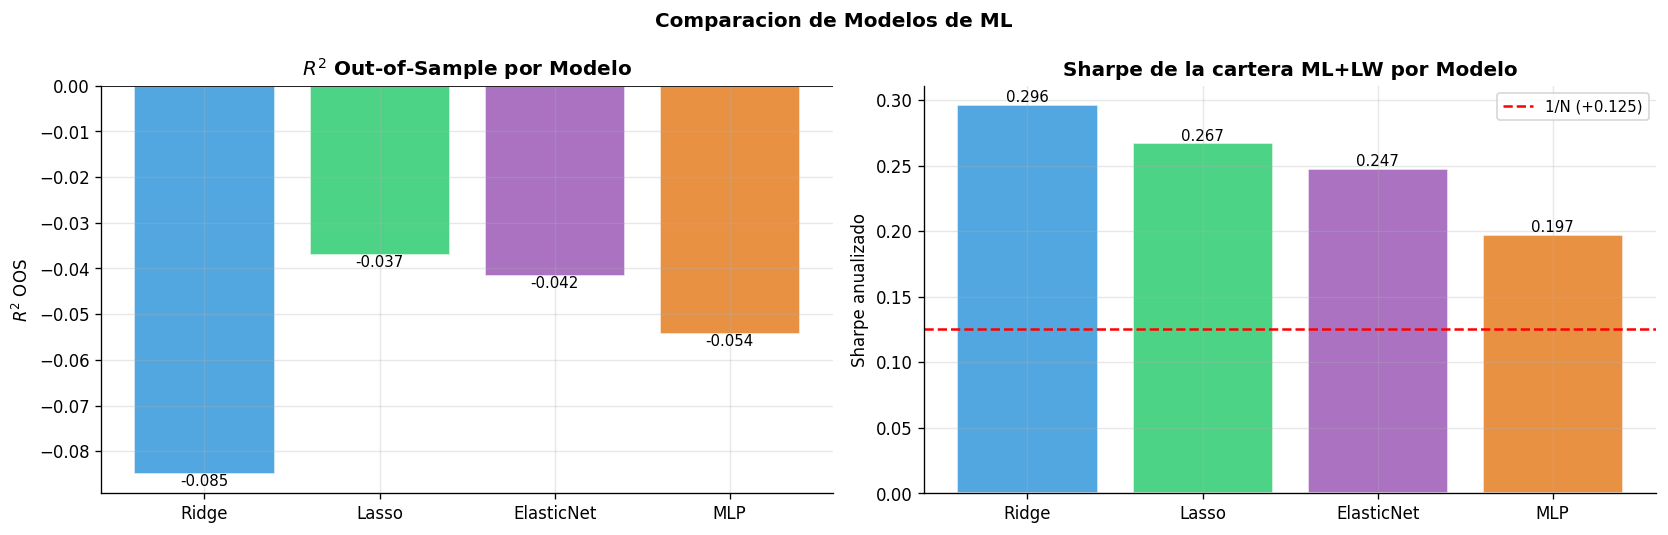

In [ ]:
# Visualizacion de la comparacion
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
modelos = comp.index.tolist()
colores = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']

axes[0].bar(modelos, comp['R2_oos'].values, color=colores, edgecolor='white', alpha=0.85)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('$R^2$ Out-of-Sample por Modelo', fontweight='bold')
axes[0].set_ylabel('$R^2$ OOS')
for i, v in enumerate(comp['R2_oos'].values):
    axes[0].text(i, v, f'{v:+.3f}', ha='center', va='bottom' if v>=0 else 'top', fontsize=9)

axes[1].bar(modelos, comp['Sharpe_ML'].values, color=colores, edgecolor='white', alpha=0.85)
axes[1].axhline(sharpe_1N, color='red', ls='--', lw=1.5, label=f'1/N ({sharpe_1N:+.3f})')
axes[1].set_title('Sharpe de la cartera ML+LW por Modelo', fontweight='bold')
axes[1].set_ylabel('Sharpe anualizado'); axes[1].legend(fontsize=9)
for i, v in enumerate(comp['Sharpe_ML'].values):
    axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparacion de Modelos de ML', fontweight='bold')
plt.tight_layout(); plt.savefig('comparacion_modelos.png', bbox_inches='tight', dpi=150); plt.show()

## Visualizaciones del backtest

Valor acumulado, drawdowns, rolling Sharpe, distribución de retornos, pesos promedio y evolución del shrinkage de Ledoit-Wolf.

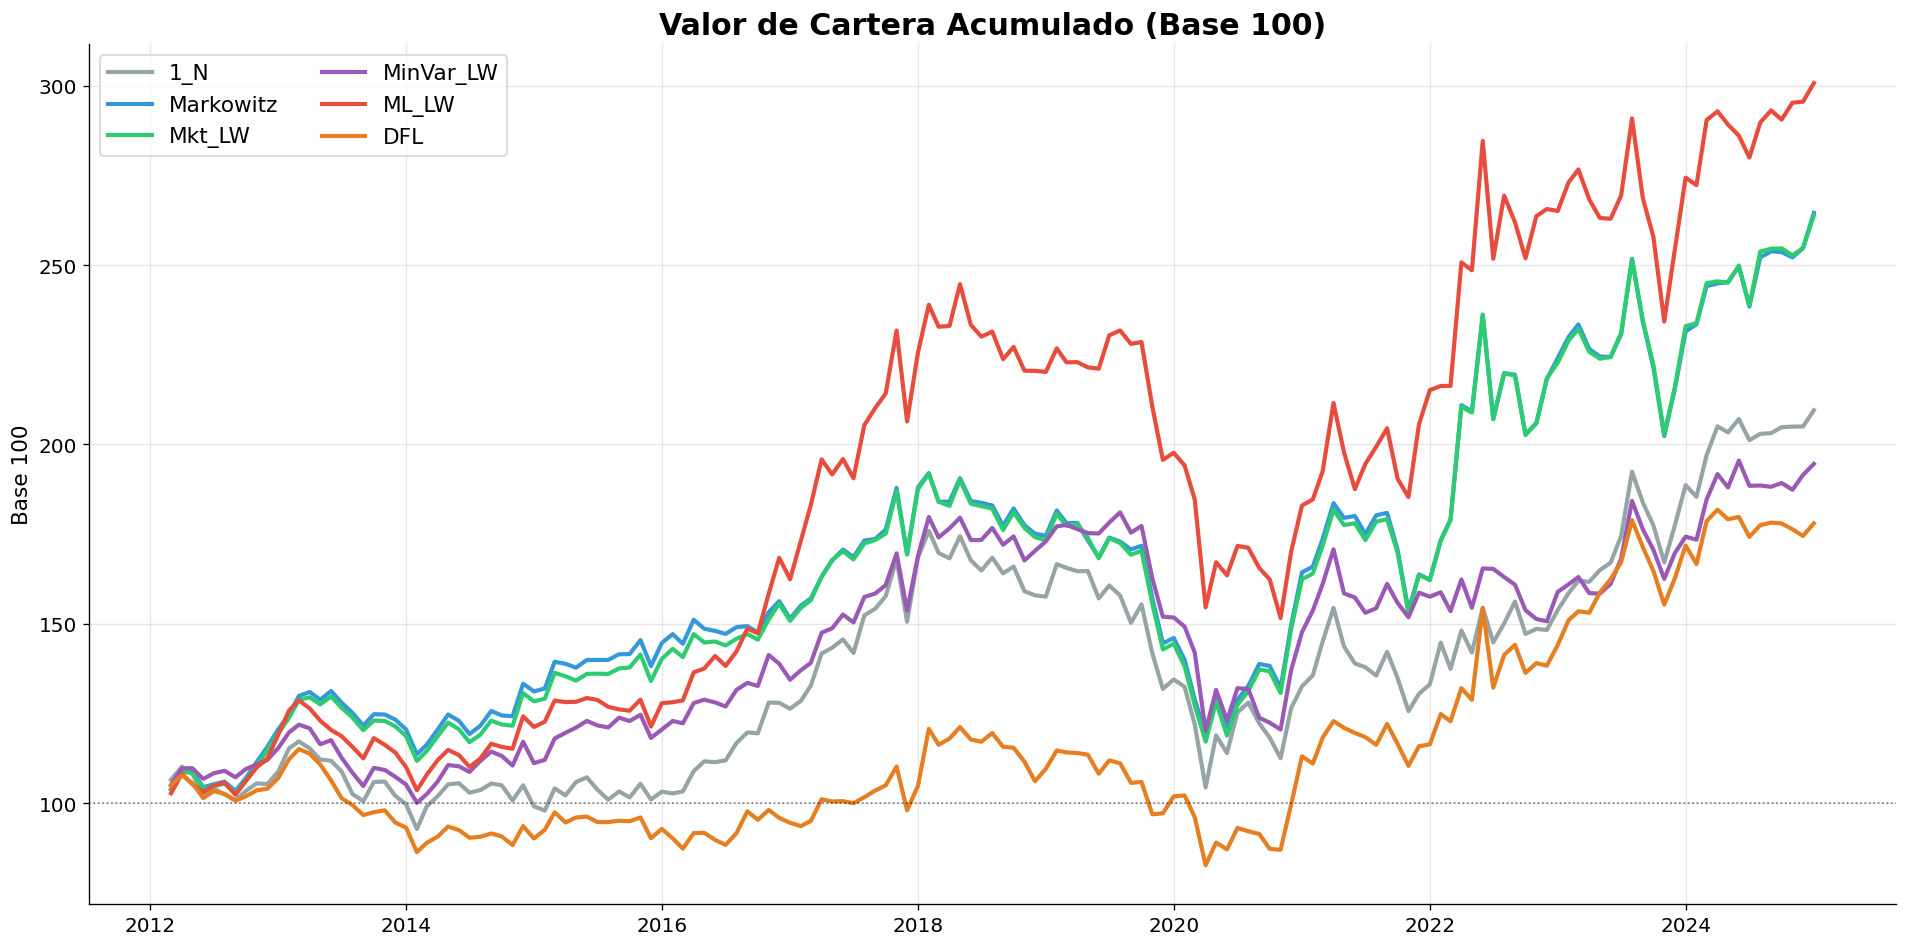

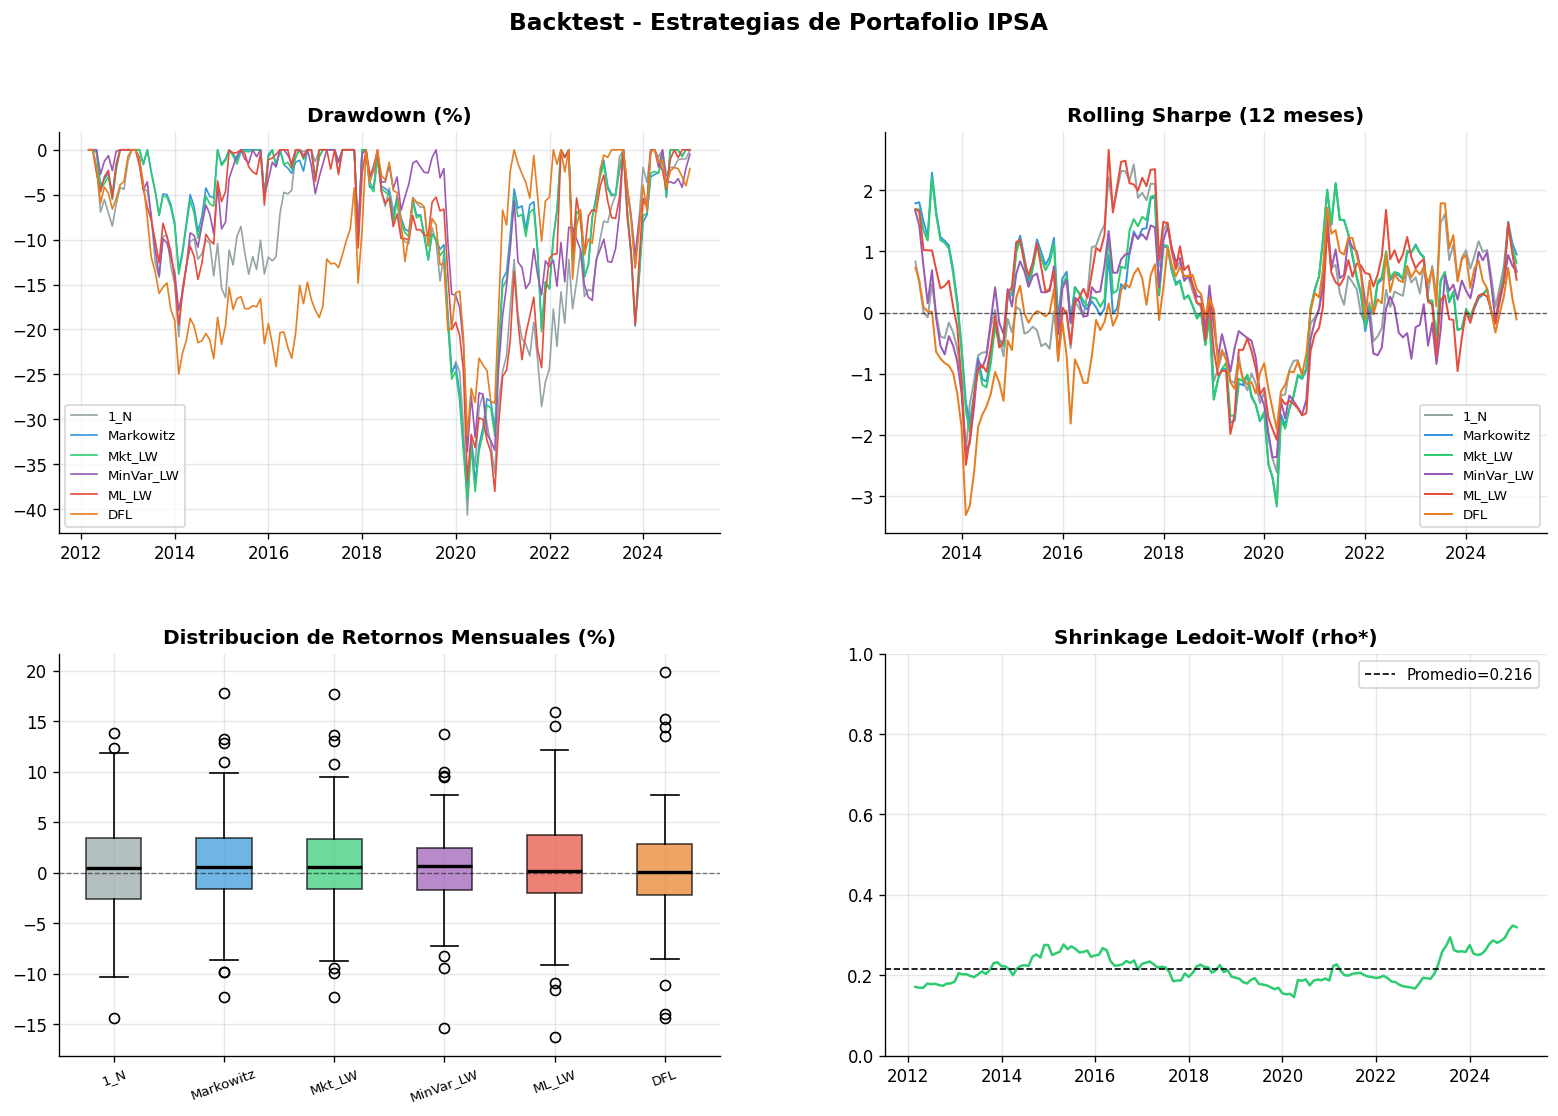

In [ ]:
COL = {'1_N':'#95a5a6','Markowitz':'#3498db','Mkt_LW':'#2ecc71',
       'MinVar_LW':'#9b59b6','ML_LW':'#e74c3c','DFL':'#e67e22'}
ESTR = list(ret_df.columns)

# Valor de Cartera
fig1, ax = plt.subplots(figsize=(16, 8))
for e in ESTR:
    ax.plot(ret_df.index, (1+ret_df[e]).cumprod()*100, color=COL[e], lw=2.5, label=e)
ax.axhline(100, color='k', ls=':', lw=1, alpha=.5)
ax.set_title('Valor de Cartera Acumulado (Base 100)', fontweight='bold', fontsize=18)
ax.set_ylabel('Base 100', fontsize=13)
ax.legend(fontsize=13, ncol=2, loc='upper left')
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('backtest_cartera.png', bbox_inches='tight', dpi=200); plt.show()


fig2 = plt.figure(figsize=(16, 10)); gs = fig2.add_gridspec(2, 2, hspace=0.30, wspace=0.25)

# Drawdowns
ax=fig2.add_subplot(gs[0,0])
for e in ESTR:
    v=(1+ret_df[e]).cumprod().values; dd=(v-np.maximum.accumulate(v))/np.maximum.accumulate(v)*100
    ax.plot(ret_df.index, dd, color=COL[e], lw=1, label=e)
ax.set_title('Drawdown (%)', fontweight='bold'); ax.legend(fontsize=8)

# Rolling Sharpe 12m
ax=fig2.add_subplot(gs[0,1])
for e in ESTR:
    ex=ret_df[e]-RF_MENSUAL
    rs=ex.rolling(12).mean()/ex.rolling(12).std()*np.sqrt(12)
    ax.plot(ret_df.index, rs, color=COL[e], lw=1.2, label=e)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=.6)
ax.set_title('Rolling Sharpe (12 meses)', fontweight='bold'); ax.legend(fontsize=8)

# Distribucion de retornos
ax=fig2.add_subplot(gs[1,0])
bp=ax.boxplot([ret_df[e]*100 for e in ESTR], labels=ESTR, patch_artist=True,
              medianprops=dict(color='black', lw=2))
for patch,e in zip(bp['boxes'],ESTR): patch.set_facecolor(COL[e]); patch.set_alpha(.7)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=.5); ax.set_xticklabels(ESTR, rotation=20, fontsize=8)
ax.set_title('Distribucion de Retornos Mensuales (%)', fontweight='bold')

# Shrinkage LW
ax=fig2.add_subplot(gs[1,1])
sh=resultados['shrinkage']
ax.plot(sh.index, sh.values, color='#2ecc71', lw=1.5)
ax.axhline(sh.mean(), color='k', ls='--', lw=1, label=f'Promedio={sh.mean():.3f}')
ax.set_ylim(0,1); ax.set_title('Shrinkage Ledoit-Wolf (rho*)', fontweight='bold'); ax.legend(fontsize=9)

plt.suptitle('Backtest - Estrategias de Portafolio IPSA', fontsize=14, fontweight='bold')
plt.savefig('backtest_panel.png', bbox_inches='tight', dpi=150); plt.show()

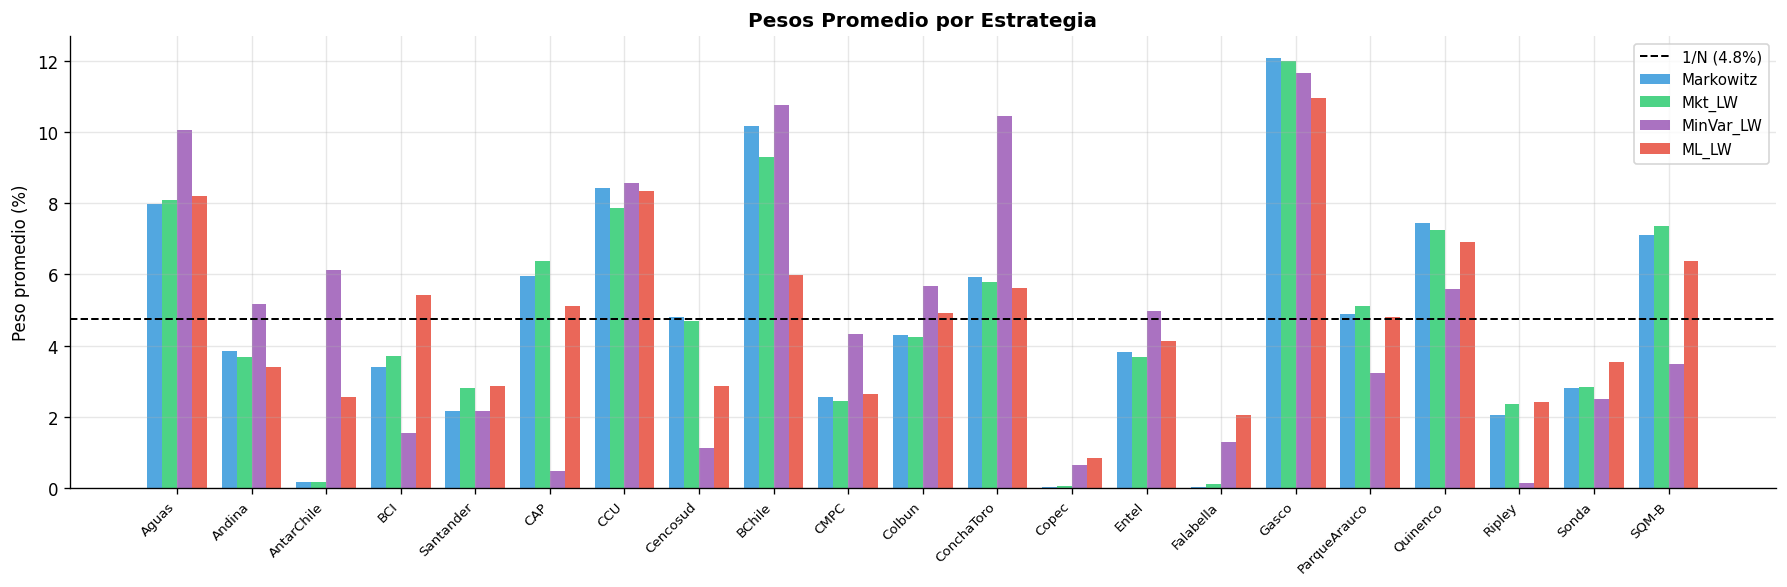

In [ ]:
# Pesos promedio por estrategia (las que optimizan)
fig, ax = plt.subplots(figsize=(15,5))
sub = ['Markowitz','Mkt_LW','MinVar_LW','ML_LW']
x=np.arange(N); wbar=0.2
for k,e in enumerate(sub):
    ax.bar(x+(k-1.5)*wbar, resultados['pesos'][e].mean().values*100, wbar, color=COL[e], alpha=.85, label=e)
ax.axhline(100/N, color='k', ls='--', lw=1.2, label=f'1/N ({100/N:.1f}%)')
ax.set_xticks(x); ax.set_xticklabels(nombres_ok, rotation=45, fontsize=8, ha='right')
ax.set_ylabel('Peso promedio (%)'); ax.set_title('Pesos Promedio por Estrategia', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('pesos.png', bbox_inches='tight', dpi=150); plt.show()

## Comparación final: estrategias actuales + versiones `_refine`

Juntamos en una sola tabla todas las estrategias de `ret_df` (típicas + ML+LW + DFL) con los modelos ML afinados por Sharpe (`_refine`), bajo la misma métrica fuera de muestra y el mismo bootstrap. El bloque final contrasta, modelo a modelo, el Sharpe **base (MSE)** contra el **refine (Sharpe)** para ver si el refinamiento aporta una mejora real.

In [ ]:
# estrategias actuales + versiones afinadas por Sharpe

ret_all = ret_df.copy()
for _m, _r in res_tune.items():
    ret_all[_m + '_refine'] = _r['serie']
ret_all = ret_all.dropna()
print(f'Estrategias comparadas ({len(ret_all)} meses):')
print('  ' + ', '.join(ret_all.columns) + '\n')

boot_all = bootstrap_sharpe(ret_all)
ref = '1_N'; s_ref = m_sharpe(ret_all[ref])
filas = []
for c in ret_all.columns:
    pe = m_sharpe(ret_all[c]); lo, hi = np.percentile(boot_all[c], [2.5, 97.5])
    if c == ref:
        p = np.nan
    else:
        dif = boot_all[c] - boot_all[ref]; p = 2 * min((dif <= 0).mean(), (dif >= 0).mean())
    filas.append({'Estrategia': c, 'Sharpe': round(pe, 3),
                  'IC95': f'[{lo:+.3f}, {hi:+.3f}]',
                  'vs_1/N': round(pe - s_ref, 3),
                  'p_vs_1N': (np.nan if c == ref else round(p, 3))})
tabla_all = pd.DataFrame(filas).set_index('Estrategia')
print('=' * 78)
print('  COMPARACION COMPLETA  (Sharpe OOS + bootstrap vs 1/N)')
print('=' * 78)
print(tabla_all.to_string())

print('\n' + '-' * 78)
print('  BASE (hiperparametros por MSE)   vs   _REFINE (por Sharpe)')
print('-' * 78)
print(f"  {'Modelo':12s} {'base (MSE)':>11s} {'refine (Sharpe)':>16s} {'delta':>9s}")
for _m in res_tune:
    sb = comp.loc[_m, 'Sharpe_ML'] if _m in comp.index else np.nan     # base por MSE
    sr = m_sharpe(ret_all[_m + '_refine'])                             # refine por Sharpe
    print(f"  {_m:12s} {sb:11.3f} {sr:16.3f} {sr - sb:+9.3f}"
          + ('  (mejora)' if sr > sb else '  (empeora)'))

_mejoras = [(_m, m_sharpe(ret_all[_m + '_refine']) - comp.loc[_m, 'Sharpe_ML'])
            for _m in res_tune if _m in comp.index]
_n_mejora = sum(1 for _, d in _mejoras if d > 0)
mejor_all = tabla_all['Sharpe'].idxmax()
print(f"\n  Mejor Sharpe global: {mejor_all} ({tabla_all.loc[mejor_all,'Sharpe']:.3f})"
      f"  |  p vs 1/N = {tabla_all.loc[mejor_all,'p_vs_1N']}")
if _n_mejora == 0:
    print('  => Ningun modelo refinado mejora su Sharpe base (MSE) fuera de muestra.')
else:
    print(f'  => {_n_mejora}/{len(_mejoras)} modelos refinados mejoran su Sharpe base (MSE) fuera de muestra.')


Estrategias comparadas (155 meses):
  1_N, Markowitz, Mkt_LW, MinVar_LW, ML_LW, DFL, Ridge_refine, Lasso_refine, ElasticNet_refine

  COMPARACION COMPLETA  (Sharpe OOS + bootstrap vs 1/N)
                   Sharpe              IC95  vs_1/N  p_vs_1N
Estrategia                                                  
1_N                 0.125  [-0.376, +0.581]   0.000      NaN
Markowitz           0.240  [-0.308, +0.738]   0.115    0.536
Mkt_LW              0.238  [-0.310, +0.740]   0.113    0.512
MinVar_LW           0.080  [-0.453, +0.554]  -0.045    0.626
ML_LW               0.296  [-0.219, +0.773]   0.171    0.234
DFL                 0.046  [-0.470, +0.488]  -0.079    0.604
Ridge_refine        0.150  [-0.382, +0.621]   0.025    0.895
Lasso_refine        0.160  [-0.355, +0.644]   0.035    0.831
ElasticNet_refine   0.044  [-0.461, +0.497]  -0.081    0.565

------------------------------------------------------------------------------
  BASE (hiperparametros por MSE)   vs   _REFINE (por Sharpe)


# 5. Análisis de significancia (Bootstrap)

## Bootstrap por bloques (significancia del Sharpe)

Para decidir si las diferencias de Sharpe son reales o ruido, aplicamos un **moving-block bootstrap** sobre los retornos fuera de muestra: 5000 réplicas, bloques de 6 meses, remuestreo **pareado** (mismas fechas para todas las estrategias). Reportamos la distribución del Sharpe, su intervalo de confianza al 95%, la comparación contra Equal-Weight (1/N) y los p-valores.

In [ ]:
boot = bootstrap_sharpe(ret_df)
ref = '1_N'; cols = list(ret_df.columns)
print(f'  BOOTSTRAP POR BLOQUES (n={N_BOOT}, bloque={BLOCK_LEN}m, test={len(ret_df)}m)')
print('-'*72)
print(f'  {"estrategia":12s} {"Sharpe":>8s} {"IC 95%":>22s}  distinto de 0')
for c in cols:
    pe=m_sharpe(ret_df[c]); lo,hi=np.percentile(boot[c],[2.5,97.5])
    print(f'  {c:12s} {pe:+8.3f}  [{lo:+.3f}, {hi:+.3f}]      {"SI" if (lo>0 or hi<0) else "no"}')
print(f'\n  Diferencia de Sharpe vs {ref} (IC95 y p-valor 2 colas):')
for c in cols:
    if c==ref: continue
    d=boot[c]-boot[ref]; lo,hi=np.percentile(d,[2.5,97.5]); p=2*min((d<=0).mean(),(d>=0).mean())
    print(f'  {c:12s} dif={m_sharpe(ret_df[c])-m_sharpe(ret_df[ref]):+.3f}  IC95=[{lo:+.3f}, {hi:+.3f}]  p={p:.3f}'
          + ('  <-- significativa' if p<0.05 else ''))

  BOOTSTRAP POR BLOQUES (n=5000, bloque=6m, test=155m)
------------------------------------------------------------------------
  estrategia     Sharpe                 IC 95%  distinto de 0
  1_N            +0.125  [-0.376, +0.581]      no
  Markowitz      +0.240  [-0.308, +0.738]      no
  Mkt_LW         +0.238  [-0.310, +0.740]      no
  MinVar_LW      +0.080  [-0.453, +0.554]      no
  ML_LW          +0.296  [-0.219, +0.773]      no
  DFL            +0.046  [-0.470, +0.488]      no

  Diferencia de Sharpe vs 1_N (IC95 y p-valor 2 colas):
  Markowitz    dif=+0.115  IC95=[-0.219, +0.446]  p=0.536
  Mkt_LW       dif=+0.113  IC95=[-0.203, +0.438]  p=0.512
  MinVar_LW    dif=-0.045  IC95=[-0.296, +0.194]  p=0.626
  ML_LW        dif=+0.171  IC95=[-0.106, +0.474]  p=0.234
  DFL          dif=-0.079  IC95=[-0.385, +0.204]  p=0.604


Matriz de p-valores (diferencia de Sharpe entre pares):
             1_N  Markowitz  Mkt_LW  MinVar_LW  ML_LW    DFL
1_N        1.000      0.536   0.512      0.626  0.234  0.604
Markowitz  0.536      1.000   0.916      0.358  0.666  0.256
Mkt_LW     0.512      0.916   1.000      0.344  0.656  0.245
MinVar_LW  0.626      0.358   0.344      1.000  0.140  0.917
ML_LW      0.234      0.666   0.656      0.140  1.000  0.157
DFL        0.604      0.256   0.245      0.917  0.157  1.000


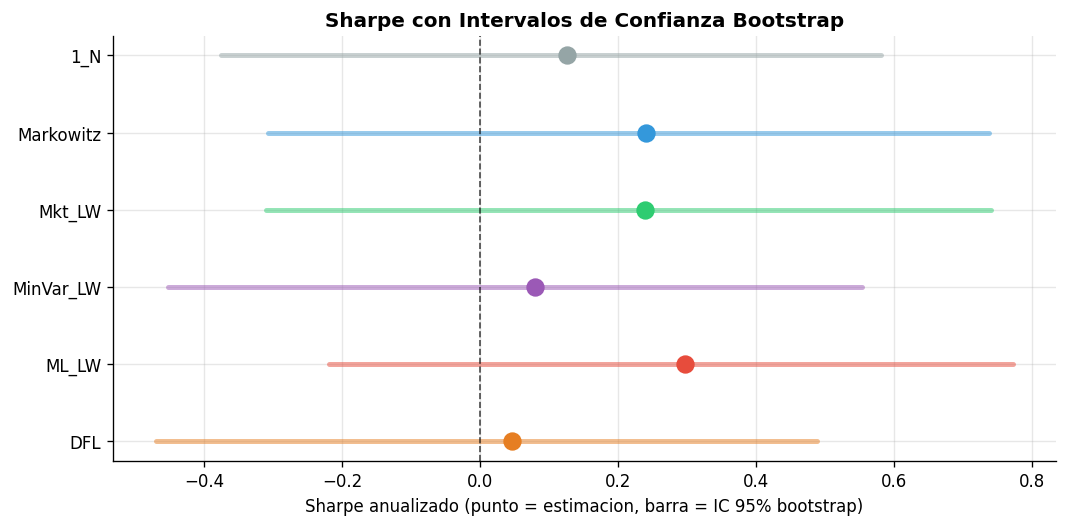


Estrategias con Sharpe significativamente > 0: 0/6
Estrategias que superan a 1/N significativamente (p<0.05): NINGUNA


In [ ]:
# Matriz de p-valores + grafico de IC bootstrap
pmat = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
for i,a in enumerate(cols):
    for j,b2 in enumerate(cols):
        if i<j:
            d=boot[a]-boot[b2]; p=2*min((d<=0).mean(),(d>=0).mean())
            pmat.loc[a,b2]=p; pmat.loc[b2,a]=p
print('Matriz de p-valores (diferencia de Sharpe entre pares):')
print(pmat.round(3).to_string())

fig, ax = plt.subplots(figsize=(9,4.5))
for i,c in enumerate(cols):
    pe=m_sharpe(ret_df[c]); lo,hi=np.percentile(boot[c],[2.5,97.5])
    ax.plot([lo,hi],[i,i], color=COL[c], lw=3, alpha=.5, solid_capstyle='round')
    ax.plot(pe,i,'o', color=COL[c], ms=10, zorder=3)
ax.axvline(0, color='k', ls='--', lw=1, alpha=.7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols); ax.invert_yaxis()
ax.set_xlabel('Sharpe anualizado (punto = estimacion, barra = IC 95% bootstrap)')
ax.set_title('Sharpe con Intervalos de Confianza Bootstrap', fontweight='bold')
plt.tight_layout(); plt.savefig('bootstrap.png', bbox_inches='tight', dpi=150); plt.show()

n_sig = sum((np.percentile(boot[c],2.5)>0) for c in cols)
sig_vs = [c for c in cols if c!=ref and 2*min(((boot[c]-boot[ref])<=0).mean(),((boot[c]-boot[ref])>=0).mean())<0.05]
print(f'\nEstrategias con Sharpe significativamente > 0: {n_sig}/{len(cols)}')
print(f'Estrategias que superan a 1/N significativamente (p<0.05): {sig_vs if sig_vs else "NINGUNA"}')